In [2]:
# === Standard Library ===
import math
import random
import time
import heapq
import itertools
from collections import defaultdict, deque
from itertools import combinations
from typing import Any, Tuple, Dict, List, Set, Sequence, Union
# === Third-Party Libraries ===

# --- Scientific Computing ---
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.optimize import linprog

# --- Plotting ---
import matplotlib.pyplot as plt

# --- Parallel Processing ---
from joblib import Parallel, delayed
from tqdm import tqdm

# --- Graph Processing ---
import networkx as nx

# --- JIT Compilation ---
from numba import njit, prange

# 1. Plotting the Standard benchmark Results

## Merging dataframes 

In [4]:
ROOT = "/home/tuguldurb/Development/Research/SCNDP/src/SCNDP/src/final"

In [ ]:


path1 = f"{ROOT}/csv/standard_benchmark/separate_by_graph/Result_ER_100_10_all.csv"
path2 = f"{ROOT}/csv/standard_benchmark/separate_by_graph/Result_BA_100_10_all.csv"
path3 = f"{ROOT}/csv/standard_benchmark/separate_by_graph/Result_SW_100_10_all.csv"

df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)
df3 = pd.read_csv(path3)

In [21]:
df = pd.concat([df1, df2, df3], ignore_index=True)

df.to_csv(f"{ROOT}/csv/standard_benchmark/Result_100_10_all.csv", index=False)

In [23]:
path4 = f"{ROOT}/csv/standard_benchmark/separate_by_graph/Result_ER_100_10_all_DIST.csv"
path5 = f"{ROOT}/csv/standard_benchmark/separate_by_graph/Result_BA_100_10_all_DIST.csv"
path6 = f"{ROOT}/csv/standard_benchmark/separate_by_graph/Result_SW_100_10_all_DIST.csv"

df4 = pd.read_csv(path4)
df5 = pd.read_csv(path5)
df6 = pd.read_csv(path6)

df_dist = pd.concat([df4, df5, df6], ignore_index=True)

df_dist.to_csv(f"{ROOT}/csv/standard_benchmark/Result_100_10_all_DIST.csv", index=False)

In [24]:
df1.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_ER_100_10_all.xlsx")
df2.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_BA_100_10_all.xlsx")
df3.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_Sw_100_10_all.xlsx")

df4.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_ER_100_10_all_DIST.xlsx")
df5.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_BA_100_10_all_DIST.xlsx")
df6.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_SW_100_10_all_DIST.xlsx")

df.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_100_10_all.xlsx")
df_dist.to_excel(f"{ROOT}/csv/standard_benchmark/excel/Result_100_10_all_DIST.xlsx")

## asign column names

In [5]:
name_map = {
  'Greedy_MIS_final': 'Greedy_MIS_local',
  'Greedy_ES_final':  'Greedy_ES_local',
  'Greedy_MIS_initial': 'Greedy_MIS_naive',
  'Greedy_ES_initial':  'Greedy_ES_naive',
}

df['algo'] = df['algo'].replace(name_map)

df.to_csv("Results_all_heuristics_sparse.csv", index=False)
df.algo.unique()

NameError: name 'df' is not defined

## plotting p-sweep results

In [13]:
path_df = f"{ROOT}/csv/standard_benchmark/Result_100_10_all.csv"
path_df_dist = f"{ROOT}/csv/standard_benchmark/Result_100_10_all_DIST.csv"

std_df = pd.read_csv(path_df)
std_df_dist = pd.read_csv(path_df_dist)

In [14]:
std_df

,model,p,algo,time,epc
0,ER,0.0,Degree-based,1.001915,0.00000
1,ER,0.0,Betweenness,0.022983,0.00000
2,ER,0.0,PageRank,0.018108,0.00000
3,ER,0.0,Greedy,0.037177,0.00000
4,ER,0.0,Greedy + Local Search,0.214162,0.00000
...,...,...,...,...,...
556,SW,1.0,GRASP + Path Relinking + Local Search,48.620620,3743.34030
557,SW,1.0,GNN (1 shot),0.058188,3739.77450
558,SW,1.0,GNN (1 shot) + Local Search,14.418485,3488.56785
559,SW,1.0,Greedy GNN,0.147938,3739.89060


In [28]:
std_df_dist

,model,name_dist,algo,time,epc
0,ER,uniform,Degree-based,1.007040,641.94435
1,ER,uniform,Betweenness,0.033125,698.38875
2,ER,uniform,PageRank,0.031685,1313.63460
3,ER,uniform,Greedy,1.345452,1012.41540
4,ER,uniform,Greedy + LS,14.938652,1152.19170
...,...,...,...,...,...
148,SW,beta,GRASP + Path Relinking + LS,12.578774,106.22565
149,SW,beta,GNN (1 shot),0.032543,145.38060
150,SW,beta,GNN (1 shot) + LS,2.794471,133.15635
151,SW,beta,Greedy GNN,0.125868,146.49795


In [17]:
name_map = {
  'Greedy + Local Search': 'Greedy + LS',
  'Greedy with MIS + Local Search': 'Greedy with MIS + LS',
  'REGA + Local Search': 'REGA + LS', 
  'GRASP + Local Search': 'GRASP + LS',
  'GRASP + Path Relinking + Local Search': 'GRASP + Path Relinking + LS',
  'GNN (1 shot) + Local Search': 'GNN (1 shot) + LS',
  'Greedy GNN + Local Search': 'Greedy GNN + LS'
}

std_df['algo'] = std_df['algo'].replace(name_map)
std_df['algo'].unique()

std_df_dist['algo'] = std_df_dist['algo'].replace(name_map)
std_df_dist['algo'].unique()

array(['Degree-based', 'Betweenness', 'PageRank', 'Greedy', 'Greedy + LS',
       'Greedy with MIS', 'Greedy with MIS + LS', 'REGA', 'REGA + LS',
       'GRASP', 'GRASP + LS', 'GRASP + Path Relinking',
       'GRASP + Path Relinking + LS', 'GNN (1 shot)', 'GNN (1 shot) + LS',
       'Greedy GNN', 'Greedy GNN + LS'], dtype=object)

In [29]:
std_df['algo'].unique()

array(['Degree-based', 'Betweenness', 'PageRank', 'Greedy',
       'Greedy + Local Search', 'Greedy with MIS',
       'Greedy with MIS + Local Search', 'REGA', 'REGA + Local Search',
       'GRASP', 'GRASP + Local Search', 'GRASP + Path Relinking',
       'GRASP + Path Relinking + Local Search', 'GNN (1 shot)',
       'GNN (1 shot) + Local Search', 'Greedy GNN',
       'Greedy GNN + Local Search'], dtype=object)

In [ ]:
for col in ["p", "epc", "time"]:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# drop the line that couldn't be converted (still NaN after coercion)
final_df = final_df.dropna(subset=["epc", "time"])

# optional: round p so the tick labels read 0.3 instead of 0.3000000004
final_df["p"] = final_df["p"].round(1)

In [29]:
def plot_graphs(
        df, df_dist, selected_algos, marker_map, 
        linestyle_map, sub_path, suffix, root_path, nodes):
  
    for name in [
        "ER",
        "BA",
        "SW"
        ]:

        df_m = df_dist[df_dist.model==name]
        plt.figure()
        for algo in selected_algos:
            sub = df_m[df_m.algo==algo]
            m = marker_map.get(algo, "o")         # default to 'o' if missing
            ls = linestyle_map.get(algo, "-")     # default to solid
            plt.plot(
                sub.name_dist, sub.epc,
                marker=m,
                linestyle=ls,
                label=algo,
                markersize=5,   
                linewidth=1.5
            )
        plt.title(f"{name} — EPC vs Distribution")
        plt.xlabel("Distribution"); plt.ylabel("EPC")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"{root_path}/{sub_path}/Result_std_{nodes}_{int(nodes*0.1)}_{name}_epc_vs_dist_{suffix}.png")
        plt.show()

        for algo in selected_algos:
            sub = df_m[df_m.algo==algo]
            m = marker_map.get(algo, "o")         
            ls = linestyle_map.get(algo, "-")   
            plt.plot(
                sub.name_dist, sub.time,
                marker=m,
                linestyle=ls,
                label=algo,
                markersize=5,   
                linewidth=1.5
            )
        plt.title(f"{name} — Time vs Distribution")
        plt.xlabel("Distribution"); plt.ylabel("Time (seconds)")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"{root_path}/{sub_path}/Result_std_{nodes}_{int(nodes*0.1)}_{name}_time_vs_dist_{suffix}.png")
        plt.show()

    for name in [
        "ER",
        "BA",
        "SW"
        ]:

        df_m = df[df.model==name]
        plt.figure()
        for algo in selected_algos:
            sub = df_m[df_m.algo==algo]
            m = marker_map.get(algo, "o")         # default to 'o' if missing
            ls = linestyle_map.get(algo, "-")     # default to solid
            plt.plot(
                sub.p, sub.epc,
                marker=m,
                linestyle=ls,
                label=algo,
                markersize=5,   
                linewidth=1.5
            )
        plt.title(f"{name} — EPC vs p")
        plt.xlabel("p"); plt.ylabel("EPC")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"{root_path}/{sub_path}/Result_std_{nodes}_{int(nodes*0.1)}_{name}_epc_vs_p_{suffix}.png")
        plt.show()

        for algo in selected_algos:
            sub = df_m[df_m.algo==algo]
            m = marker_map.get(algo, "o")         
            ls = linestyle_map.get(algo, "-")   
            plt.plot(
                sub.p, sub.time,
                marker=m,
                linestyle=ls,
                label=algo,
                markersize=5,   
                linewidth=1.5
            )
        plt.title(f"{name} — Time vs p")
        plt.xlabel("p"); plt.ylabel("Time (seconds)")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"{root_path}/{sub_path}/Result_std_{nodes}_{int(nodes*0.1)}_{name}_time_vs_p_{suffix}.png")
        plt.show()

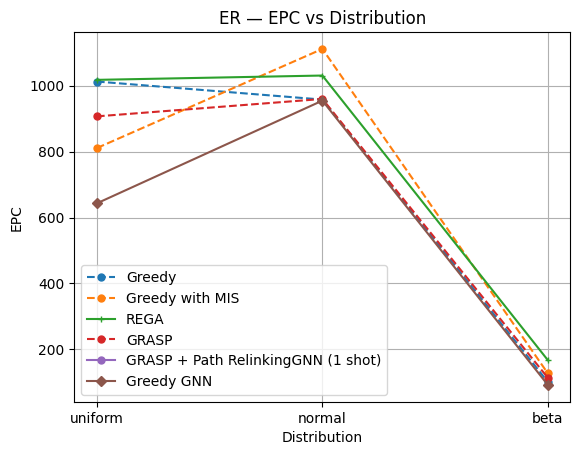

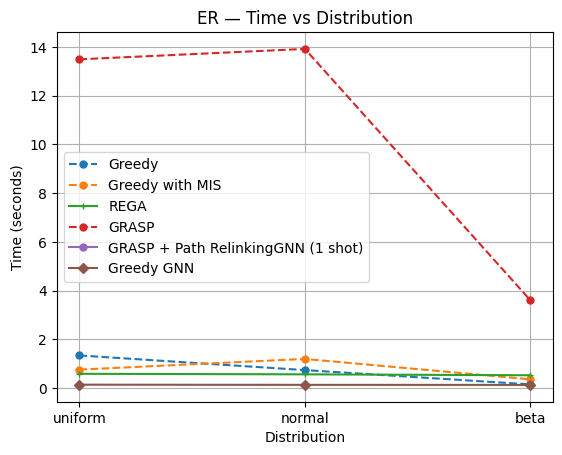

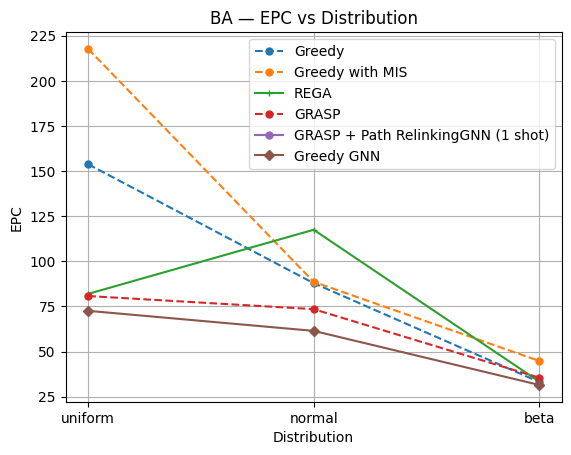

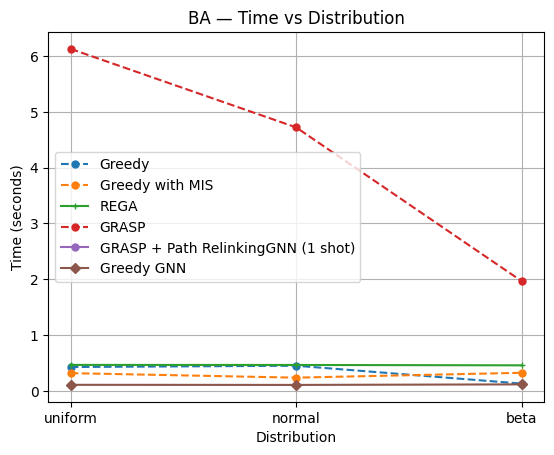

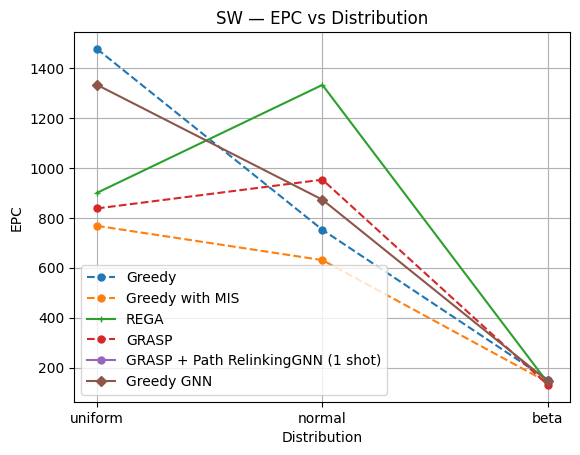

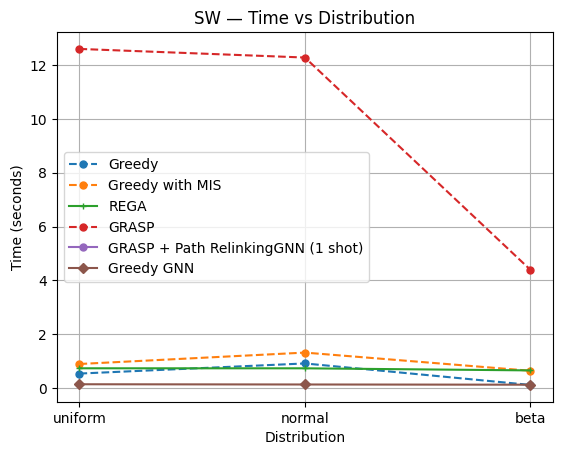

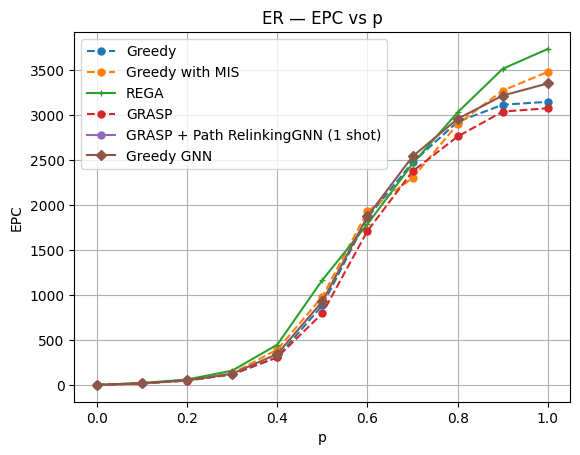

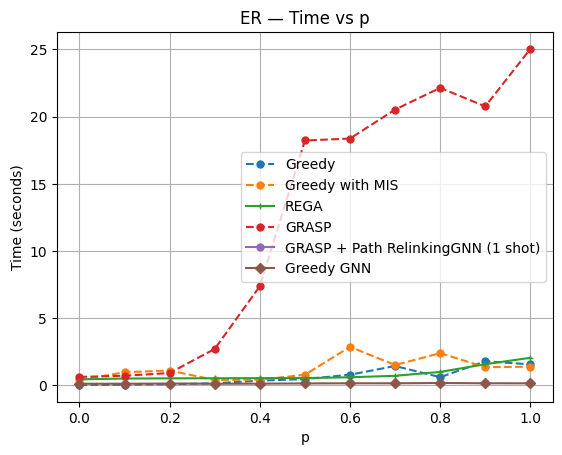

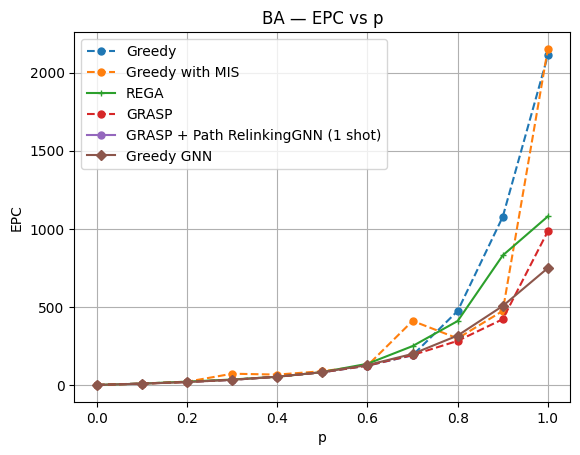

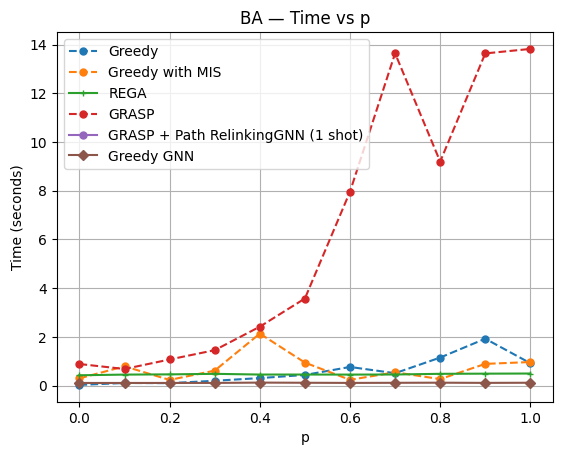

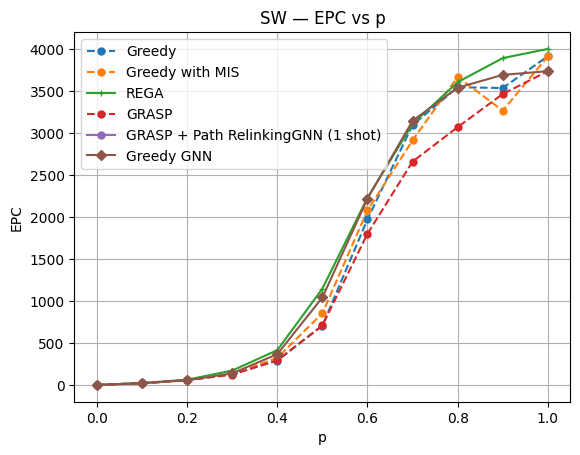

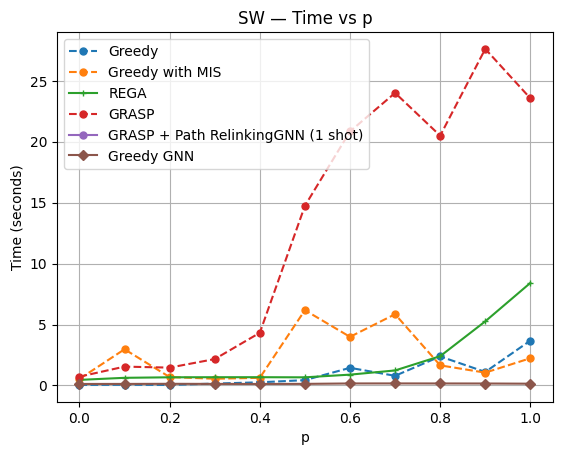

In [33]:
PLOT_PATH = f"{ROOT}/results/plot"
NODES = 100

sub_path = "standard_benchmark/no_ls_no_centrality"
suffix = "no_ls_no_centrality"

import os

os.makedirs(os.path.join(PLOT_PATH, sub_path), exist_ok=True)

selected_algos = [
  # 'Degree-based', 
  # 'Betweenness', 
  # 'PageRank', 

  'Greedy', 
  'Greedy with MIS', 

  'REGA', 
  'GRASP', 
  'GRASP + Path Relinking'

  'GNN (1 shot)', 
  'Greedy GNN'
]

marker_map = {
    'Degree-based': "x",
    'Betweenness': "x",
    'PageRank': "x",
    
    'Greedy': "o",
    'Greedy with MIS': "o",

    'REGA': "+",
    'GRASP': "o",
    'GRASP + Path Relinking': "+",

    'GNN (1 shot)': "s",
    'Greedy GNN': "D",
}

linestyle_map = {
    'Degree-based': ':',
    'Betweenness': ':',
    'PageRank': ':',

    'Greedy': '--',
    'Greedy with MIS': '--',

    'REGA': '-',
    'GRASP': '--',
    'GRASP + Path Relinking': '-',

    'GNN (1 shot)': '-',
    'Greedy GNN': '-',
}


plot_graphs(
  std_df, std_df_dist, selected_algos, marker_map, 
  linestyle_map, sub_path, suffix, PLOT_PATH, NODES)

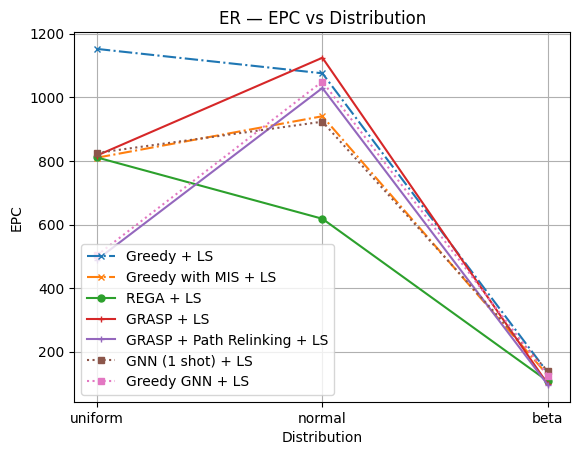

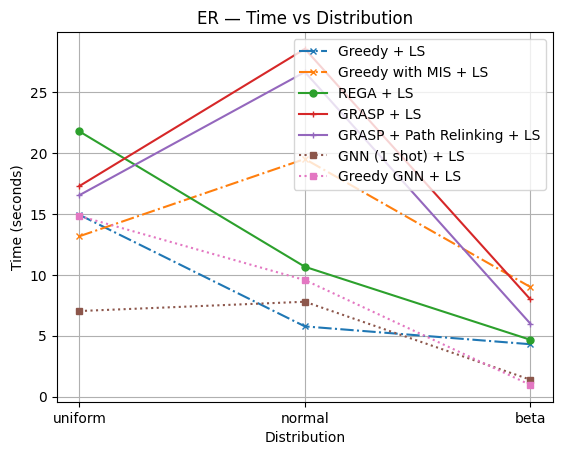

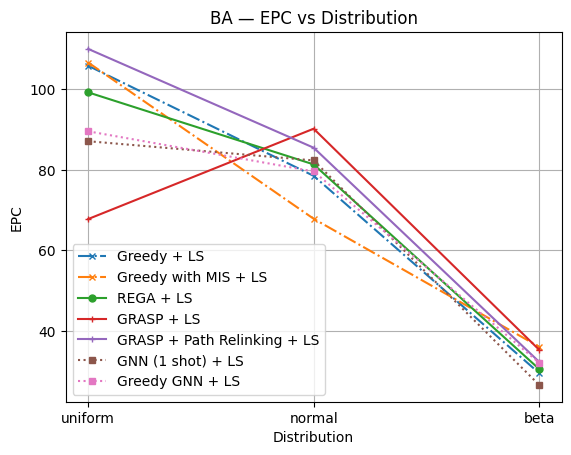

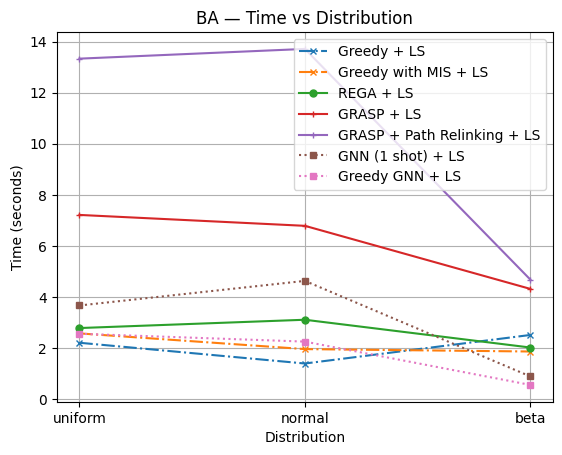

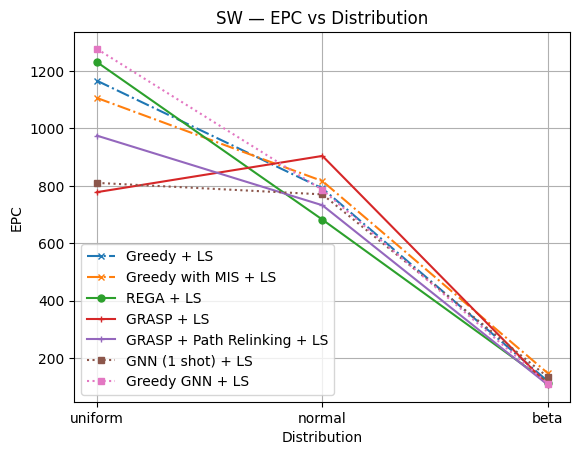

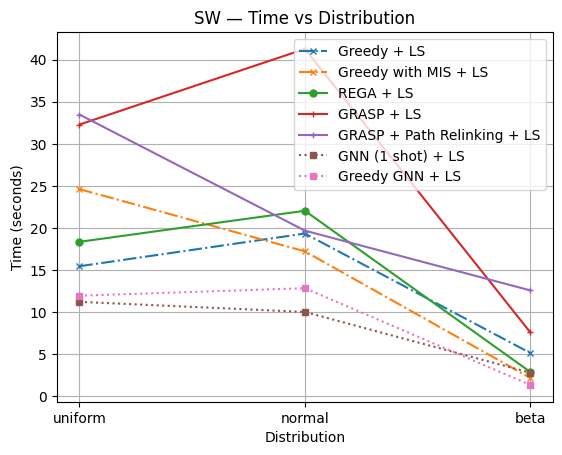

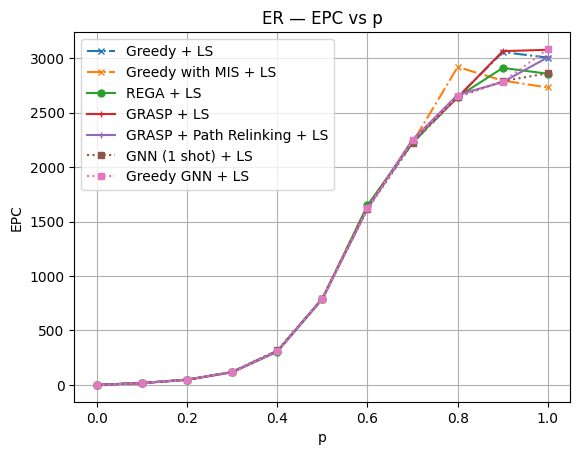

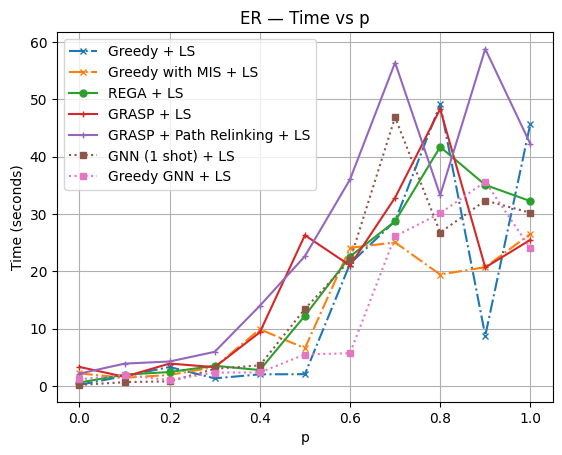

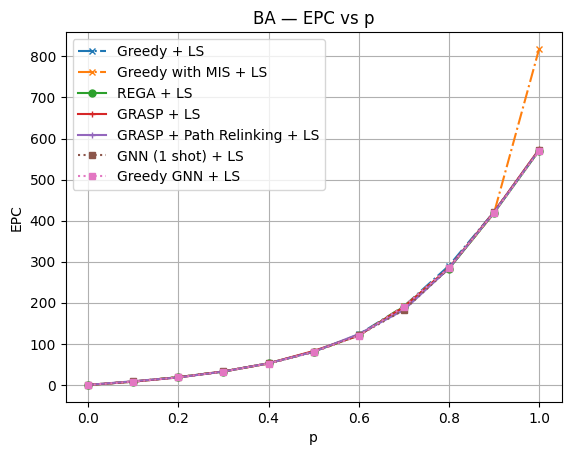

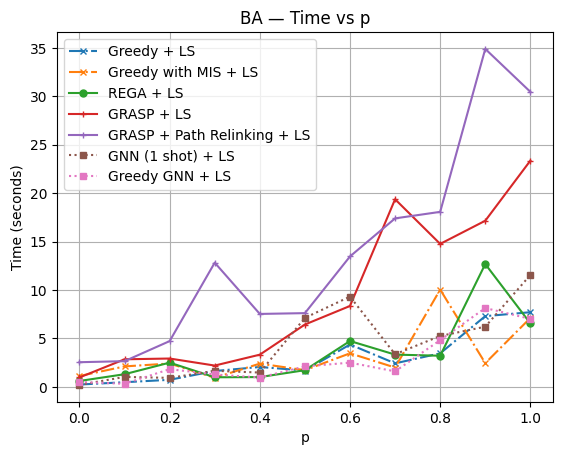

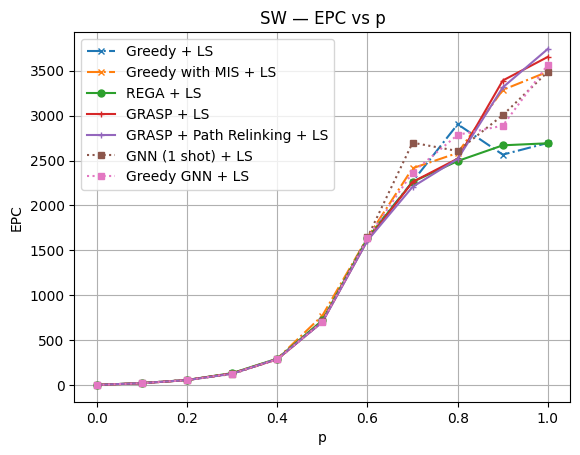

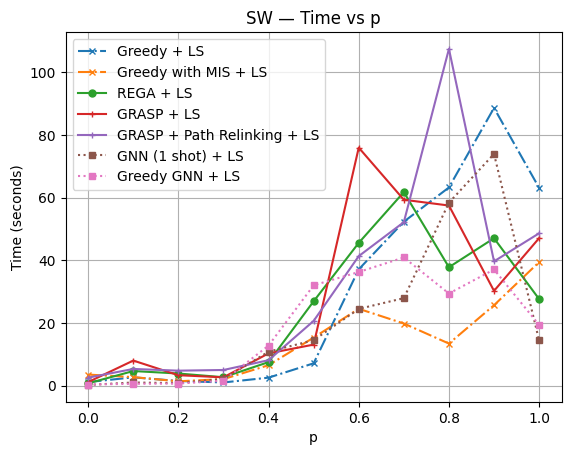

In [34]:
PLOT_PATH = f"{ROOT}/results/plot"
NODES = 100

sub_path = "standard_benchmark/with_ls"
suffix = "with_ls"

import os

os.makedirs(os.path.join(PLOT_PATH, sub_path), exist_ok=True)

selected_algos = [
  'Greedy + LS', 
  'Greedy with MIS + LS', 
  'REGA + LS', 
  'GRASP + LS', 
  'GRASP + Path Relinking + LS',
  'GNN (1 shot) + LS', 
  'Greedy GNN + LS'
]

marker_map = {
    'Greedy + LS': "x",
    'Greedy with MIS + LS': "x",

    'REGA + LS': "o",
    'GRASP + LS': "+",
    'GRASP + Path Relinking + LS': "+",

    'GNN (1 shot) + LS': "s",
    'Greedy GNN + LS': "s",
}

linestyle_map = {
    'Greedy + LS': '-.',
    'Greedy with MIS + LS': '-.',

    'REGA + LS': '-',
    'GRASP + LS': '-',
    'GRASP + Path Relinking + LS': '-',

    'GNN (1 shot) + LS': ':',
    'Greedy GNN + LS': ':',
}

plot_graphs(
  std_df, std_df_dist, selected_algos, marker_map, 
  linestyle_map, sub_path, suffix, PLOT_PATH, NODES)

# 2. Large Graphs

## Merging Dataframes

In [35]:
ROOT = "/home/tuguldurb/Development/Research/SCNDP/src/SCNDP/src/final"

In [37]:


path1 = f"{ROOT}/csv/large/Result_ER_200_20_all_large_DIST.csv"
path2 = f"{ROOT}/csv/large/Result_BA_200_20_all_large_DIST.csv"
path3 = f"{ROOT}/csv/large/Result_SW_200_20_all_large_DIST.csv"

df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)
df3 = pd.read_csv(path3)

In [39]:
df = pd.read_csv(f"{ROOT}/csv/large/Result_200_20_all_large.csv")

In [40]:
df_dist = pd.concat([df1, df2, df3], ignore_index=True)

df_dist.to_csv(f"{ROOT}/csv/large/Result_200_20_all_DIST.csv", index=False)

In [42]:
df.to_excel(f"{ROOT}/csv/large/excel/Result_200_20_all.xlsx")
df_dist.to_excel(f"{ROOT}/csv/large/excel/Result_200_20_all_DIST.xlsx")

## 200 nodes

In [44]:
path_df = f"{ROOT}/csv/large/Result_200_20_all_large.csv"
path_df_dist = f"{ROOT}/csv/large/Result_200_20_all_DIST.csv"

large_df_200 = pd.read_csv(path_df)
large_df_200_dist = pd.read_csv(path_df_dist)

In [45]:
large_df_200


,model,p,algo,time,epc
0,ER,0.1,Degree-based,0.990059,149.2164
1,ER,0.1,Betweenness,0.050356,152.7687
2,ER,0.1,PageRank,0.006607,150.3747
3,ER,0.1,Greedy,0.411592,187.8489
4,ER,0.1,Greedy + Local Search,59.613011,171.0441
...,...,...,...,...,...
325,SW,1.0,Greedy with MIS + Local Search,419.958003,14879.2482
326,SW,1.0,GNN (1 shot),0.091968,15577.0560
327,SW,1.0,GNN (1 shot) + Local Search,409.604540,13373.6130
328,SW,1.0,Greedy GNN,0.629635,15403.5000


In [46]:
large_df_200_dist

,model,name_dist,algo,time,epc
0,ER,uniform,Degree-based,1.469750,15261.6267
1,ER,uniform,Betweenness,0.247015,15126.0615
2,ER,uniform,PageRank,0.207617,14728.1526
3,ER,uniform,Greedy,15.299180,15123.7134
4,ER,uniform,Greedy + Local Search,785.170626,14935.3299
...,...,...,...,...,...
94,SW,beta,Greedy with MIS + Local Search,37.190811,258.9687
95,SW,beta,GNN (1 shot),0.062393,313.6986
96,SW,beta,GNN (1 shot) + Local Search,40.851387,240.2451
97,SW,beta,Greedy GNN,0.655054,239.7015


In [48]:
name_map = {
  'Greedy + Local Search': 'Greedy + LS',
  'Greedy with MIS + Local Search': 'Greedy with MIS + LS',
  'REGA + Local Search': 'REGA + LS', 
  'GRASP + Local Search': 'GRASP + LS',
  'GRASP + Path Relinking + Local Search': 'GRASP + Path Relinking + LS',
  'GNN (1 shot) + Local Search': 'GNN (1 shot) + LS',
  'Greedy GNN + Local Search': 'Greedy GNN + LS'
}

large_df_200['algo'] = large_df_200['algo'].replace(name_map)
large_df_200['algo'].unique()



array(['Degree-based', 'Betweenness', 'PageRank', 'Greedy', 'Greedy + LS',
       'Greedy with MIS', 'Greedy with MIS + LS', 'GNN (1 shot)',
       'GNN (1 shot) + LS', 'Greedy GNN', 'Greedy GNN + LS'], dtype=object)

In [49]:
large_df_200_dist['algo'] = large_df_200_dist['algo'].replace(name_map)
large_df_200_dist['algo'].unique()

array(['Degree-based', 'Betweenness', 'PageRank', 'Greedy', 'Greedy + LS',
       'Greedy with MIS', 'Greedy with MIS + LS', 'GNN (1 shot)',
       'GNN (1 shot) + LS', 'Greedy GNN', 'Greedy GNN + LS'], dtype=object)

## Plotting

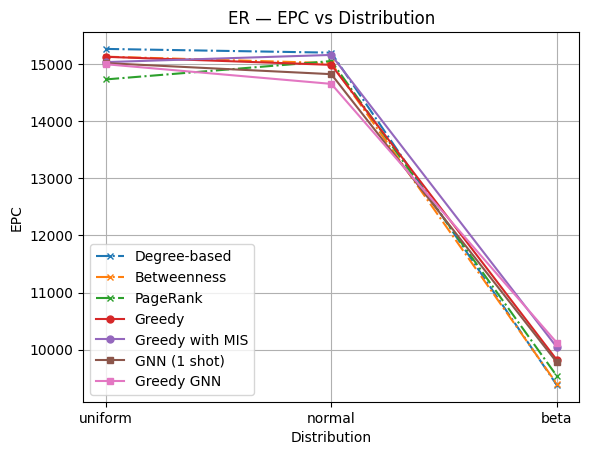

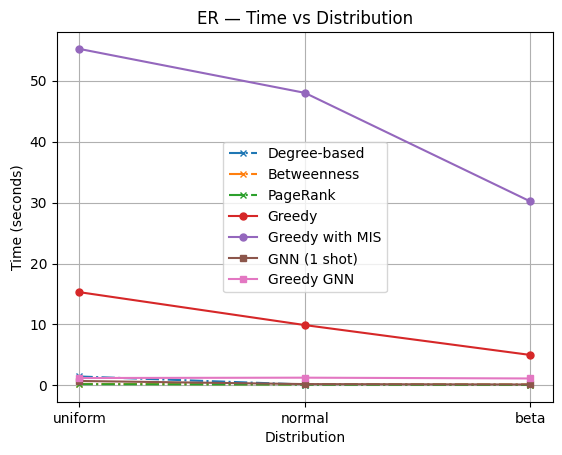

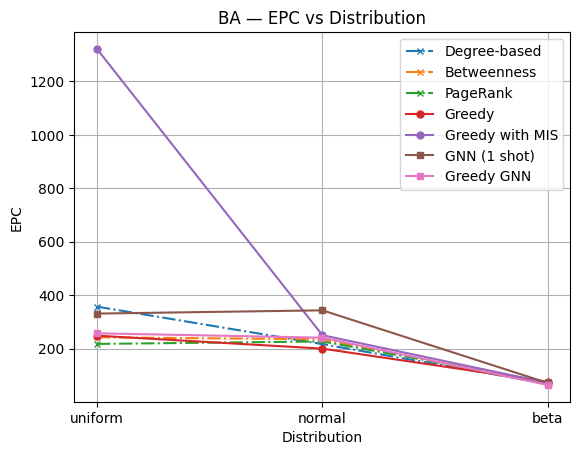

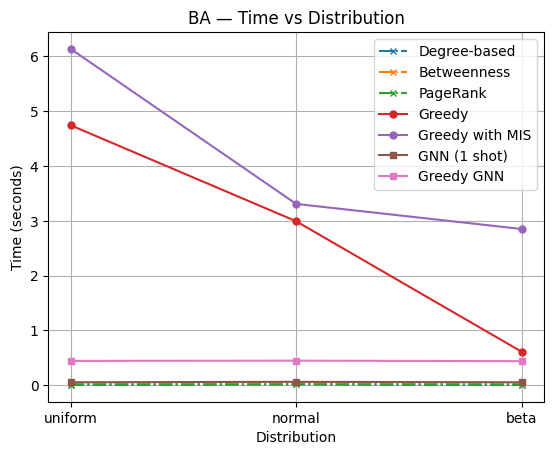

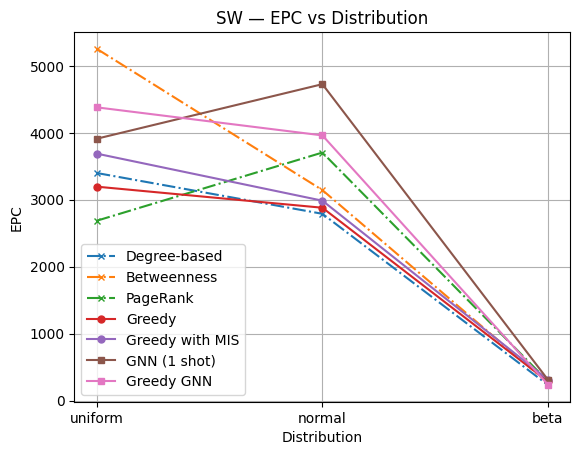

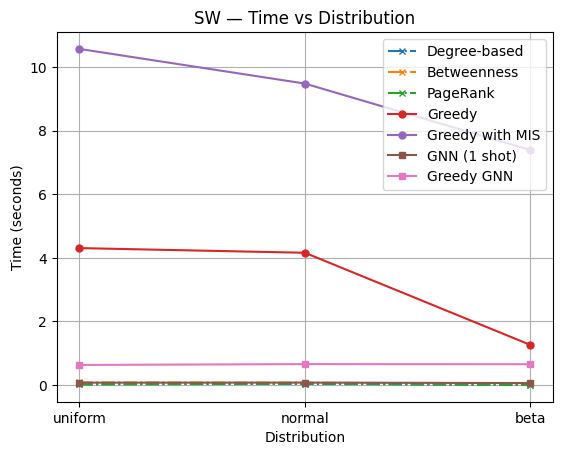

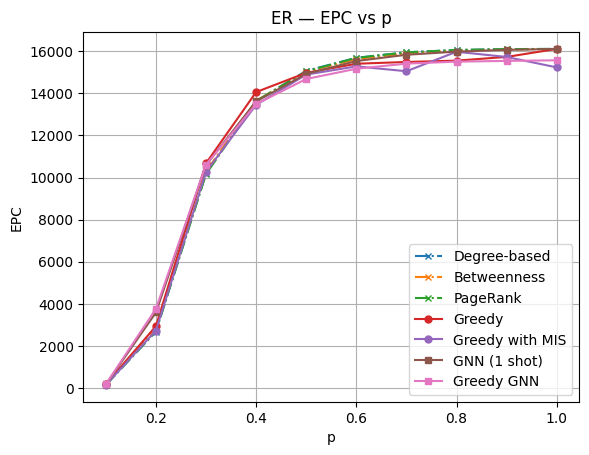

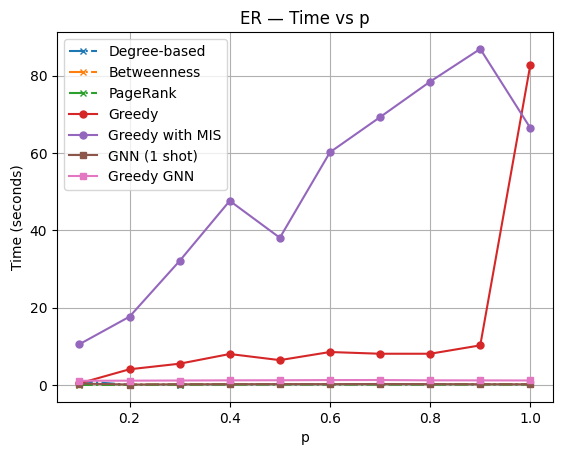

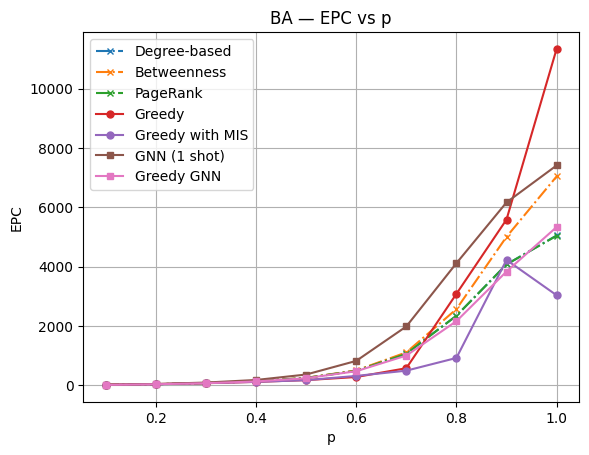

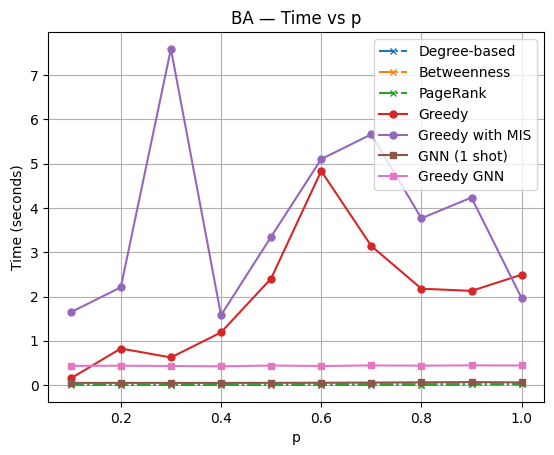

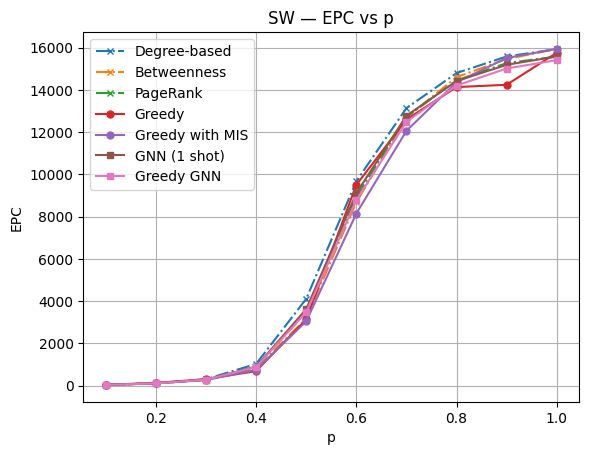

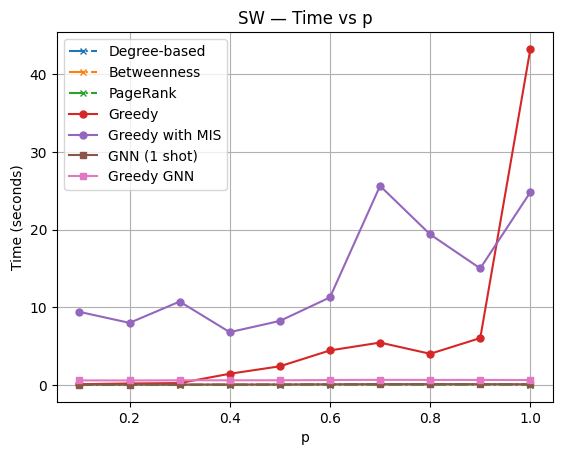

In [50]:
PLOT_PATH = f"{ROOT}/results/plot"
NODES = 200

sub_path = "large/no_ls"
suffix = "no_ls"

import os

os.makedirs(os.path.join(PLOT_PATH, sub_path), exist_ok=True)

selected_algos = [
  'Degree-based', 
  'Betweenness', 
  'PageRank', 
  'Greedy', 
  'Greedy with MIS', 
  'GNN (1 shot)',
  'Greedy GNN', 
  ] 

marker_map = {
  'Degree-based': "x",
  'Betweenness': "x",
  'PageRank': "x", 

  'Greedy': 'o',
  'Greedy with MIS': 'o',

  'GNN (1 shot)': "s",
  'Greedy GNN': "s",
}

linestyle_map = {
  'Degree-based': "-.",
  'Betweenness': "-.",
  'PageRank': "-.", 

  'Greedy': '-',
  'Greedy with MIS': '-',

  'GNN (1 shot)': "-",
  'Greedy GNN': "-",
}

plot_graphs(
  large_df_200, large_df_200_dist, selected_algos, marker_map, 
  linestyle_map, sub_path, suffix, PLOT_PATH, NODES)

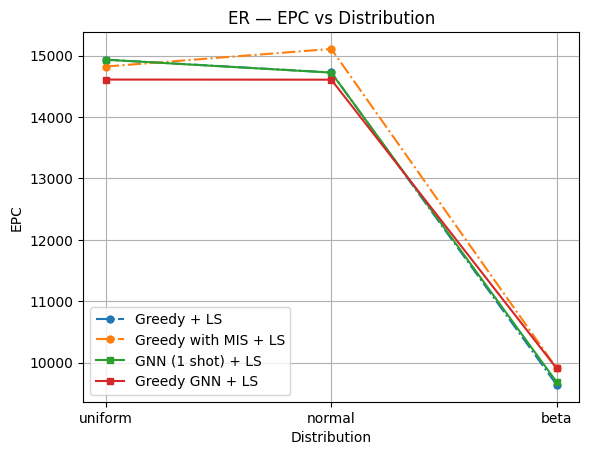

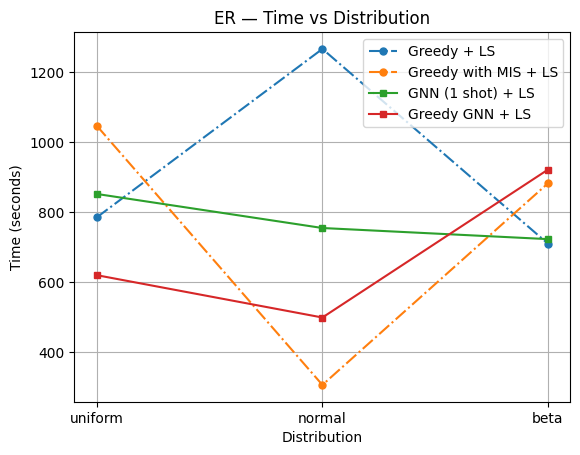

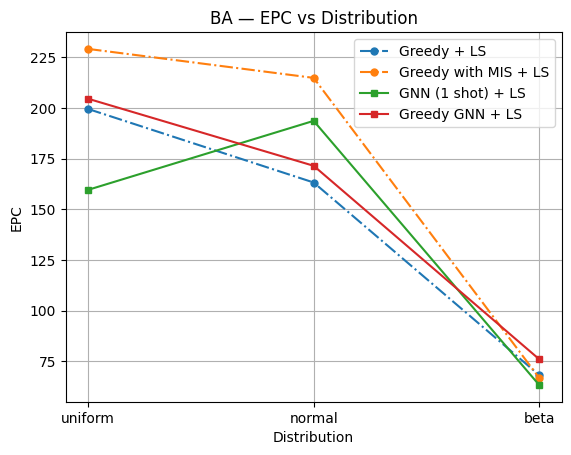

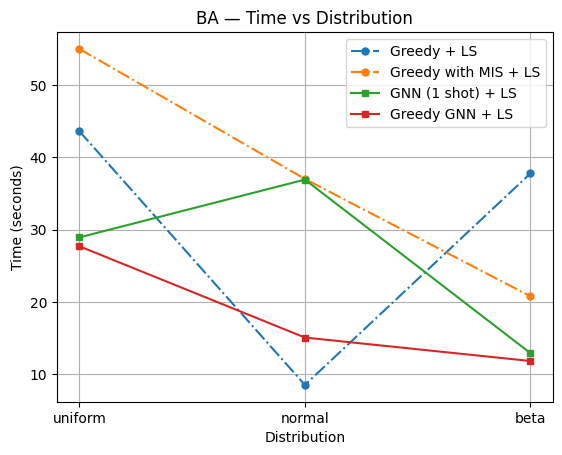

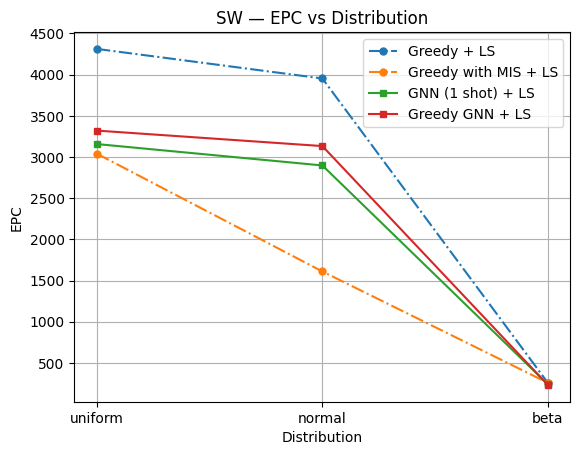

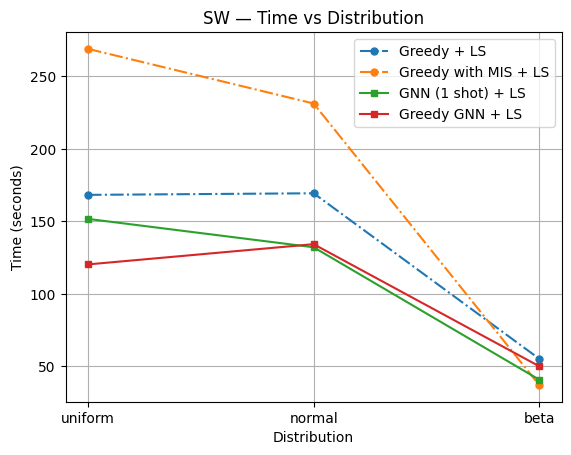

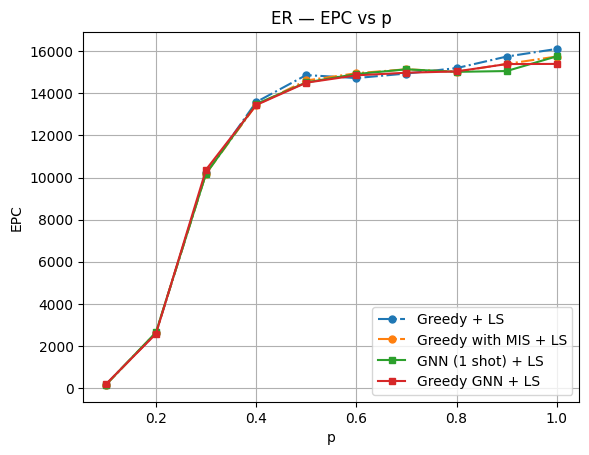

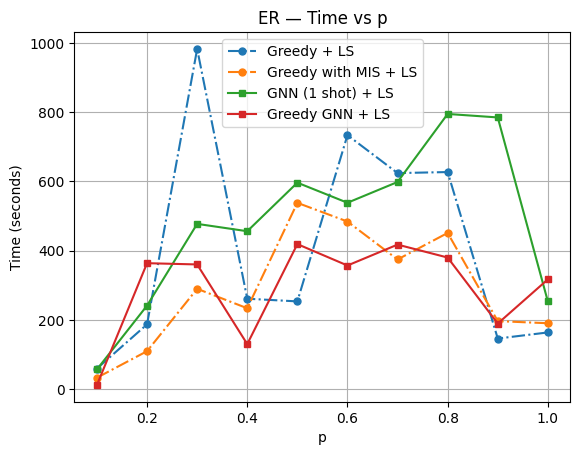

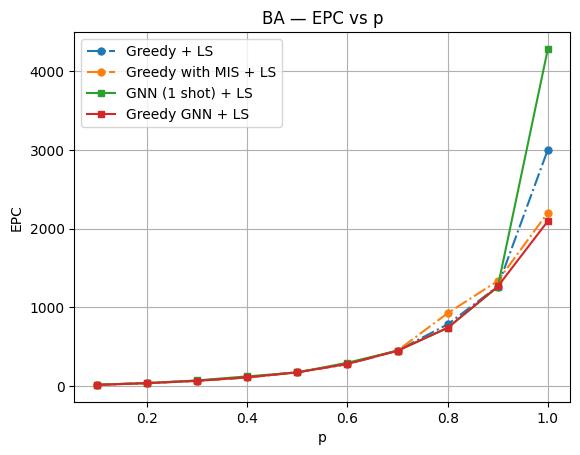

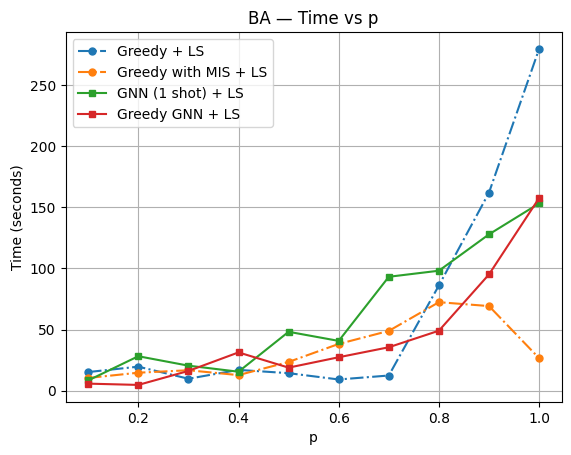

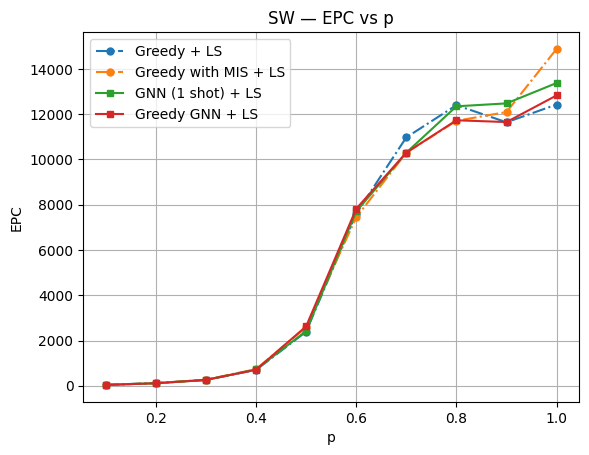

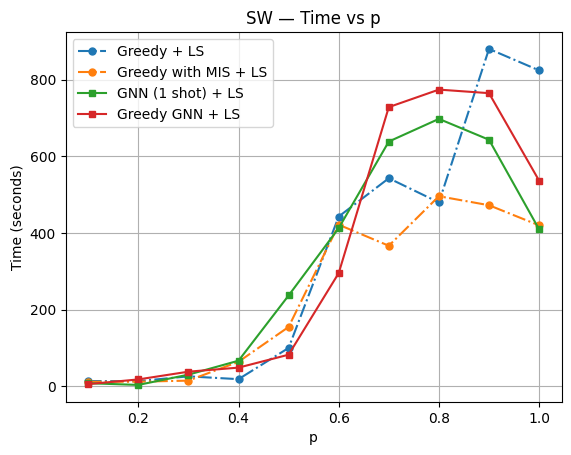

In [53]:
PLOT_PATH = f"{ROOT}/results/plot"
NODES = 200

sub_path = "large/with_ls"
suffix = "with_ls"

import os

os.makedirs(os.path.join(PLOT_PATH, sub_path), exist_ok=True)

selected_algos = [
  'Greedy + LS', 
  'Greedy with MIS + LS', 
  'GNN (1 shot) + LS',
  'Greedy GNN + LS', 
  ] 

marker_map = {
  'Greedy + LS': 'o',
  'Greedy with MIS + LS': 'o',

  'GNN (1 shot) + LS': "s",
  'Greedy GNN + LS': "s",
}

linestyle_map = {
  'Greedy + LS': '-.',
  'Greedy with MIS + LS': '-.',

  'GNN (1 shot) + LS': "-",
  'Greedy GNN + LS': "-",
}

plot_graphs(
  large_df_200, large_df_200_dist, selected_algos, marker_map, 
  linestyle_map, sub_path, suffix, PLOT_PATH, NODES)